In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   MRPy import MRPy

### Apresentação dos registros de dados adquiridos

### Cáculo da fraquencia natural e o respectivo periodo e o amortecimento:

 fs = 212.9Hz
 Td = 20.4s

 NX = 3
 N  = 4348
 M  = 2175



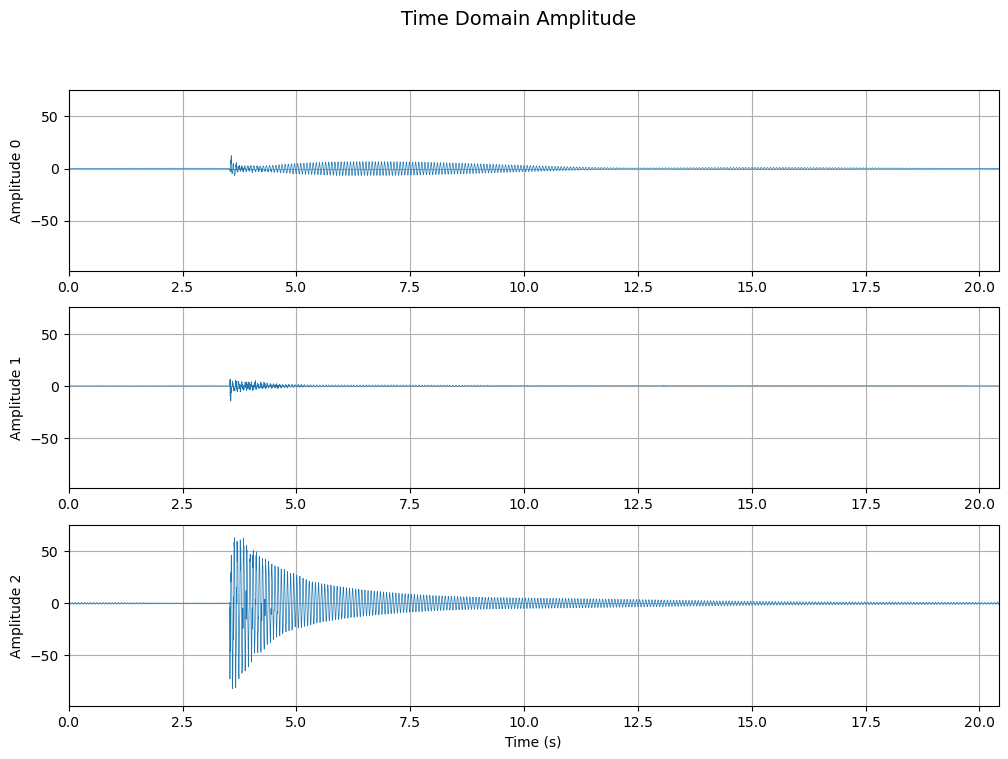

In [15]:
data = MRPy.from_file('data/leitura', form='invh')

data.printAttrib()
data.plot_time(fig=1);

 fs = 212.9Hz
 Td = 20.4s

 NX = 3
 N  = 4348
 M  = 2175



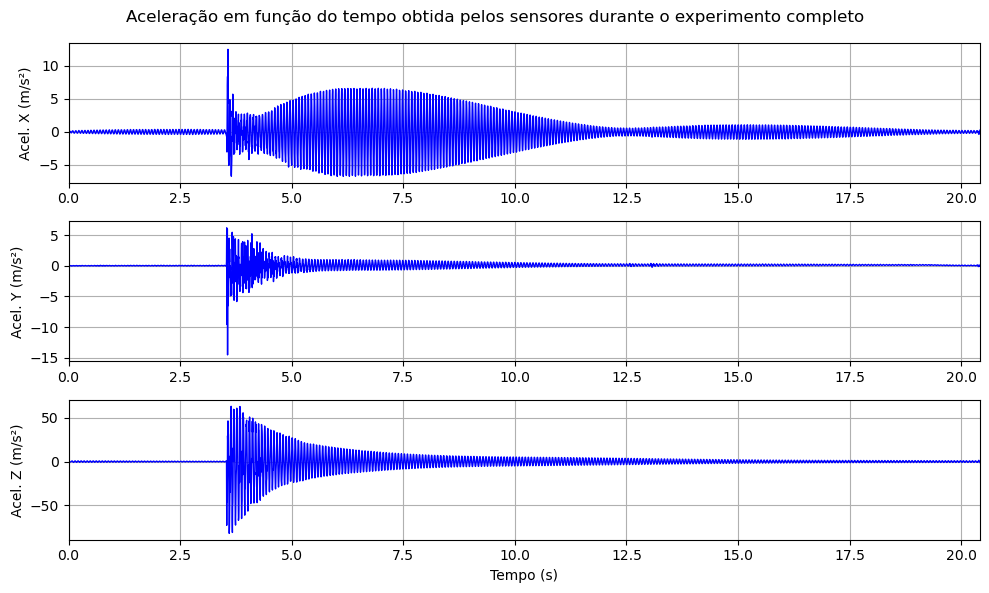

In [16]:
import matplotlib.pyplot as plt

data.printAttrib()

# Cria a figura e define os nomes que você quer usar

plt.figure(1, figsize=(10, 6), clear=True)

# Adição do título geral para os três subgráficos
plt.suptitle('Aceleração em função do tempo obtida pelos sensores durante o experimento completo')

nomes_eixos = ['Acel. X (m/s²)', 'Acel. Y (m/s²)', 'Acel. Z (m/s²)']
t = data.t_axis()

for i, acc in enumerate(data):
    plt.subplot(3, 1, i+1)
    plt.plot(t, acc, color='blue', linewidth=1)
    
    # Aplica o nome correspondente da nossa lista
    plt.ylabel(nomes_eixos[i])
    plt.grid(True)
    # Limita o eixo X para os 110 segundos do seu ensaio
    plt.xlim(0, data.Td)

plt.xlabel('Tempo (s)')
plt.tight_layout()



 fs = 212.9Hz
 Td = 20.4s

 NX = 3
 N  = 4348
 M  = 2175



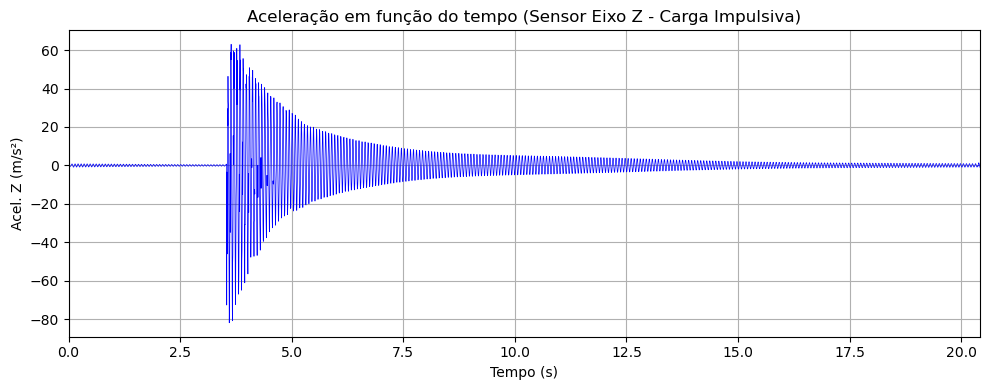

In [24]:
import matplotlib.pyplot as plt

data.printAttrib()

# Cria a figura um pouco mais baixa (figsize ajustado) por ser apenas um gráfico
plt.figure(1, figsize=(10, 4), clear=True)

t = data.t_axis()

# Isolando os dados do Eixo Z (Índice 2)
acc_z = data[2]

plt.plot(t, acc_z, color='blue', linewidth=0.5)

# Adicionando os textos e rótulos
plt.title('Aceleração em função do tempo (Sensor Eixo Z - Carga Impulsiva)')
plt.ylabel('Acel. Z (m/s²)')
plt.xlabel('Tempo (s)')

plt.grid(True)

# Limita o eixo X para os 110 segundos do seu ensaio (ou o tempo total Td)
plt.xlim(0, data.Td)

plt.tight_layout()

In [19]:
m = 1 # Massa dos sitema =1 kg
zt = 0.01 # Amortecimento
Tn = np.linspace(0.1, 10, 100) # Período estimado = 10 s
fn = 1/Tn # Frequência natural do sistema em Hz
u0 = 0. # Deslocamento inicial
v0 = 0. # Velocidade inicial

DESLOCAMENTO - Pico máximo: 231.18 mm
DESLOCAMENTO - Valor R.M.S.: 99.18 mm


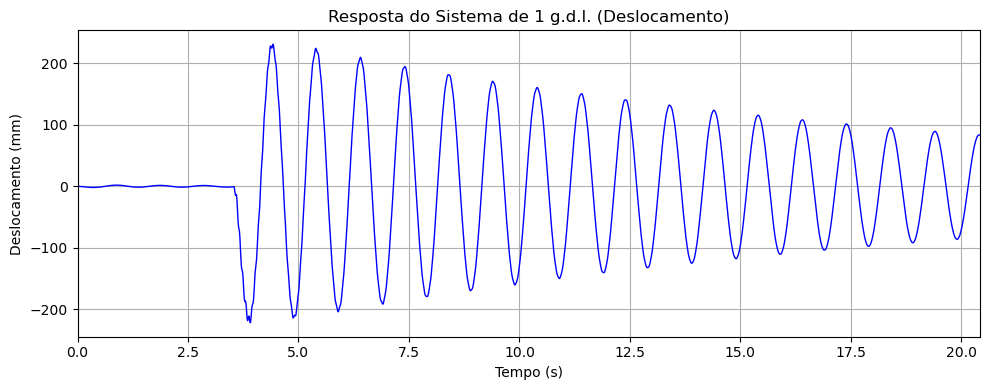

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from MRPy import MRPy

# 1. Transformar o Eixo Z isolado de volta em um objeto MRPy para usar as funções nativas
acc_z_mrpy = MRPy(data[2], fs=data.fs)

# 2. Definir o SEU sistema único exigido no trabalho
m = 1.0       # Massa (kg)
fn = 1.0      # Frequência Natural (Hz)
zeta = 0.01   # Amortecimento (1%)

# 3. Calcular a resposta (Deslocamento) usando a Integral de Duhamel
# O Duhamel do MRPy já devolve um objeto MRPy novinho com a resposta no tempo!
u = acc_z_mrpy.sdof_Duhamel(fn, zeta) / m

# 4. Apresentar os resultados de Pico e RMS do Deslocamento
u_mm = u[0] * 1000  # Convertendo para milímetros para facilitar a leitura
print(f"DESLOCAMENTO - Pico máximo: {np.max(np.abs(u_mm)):.2f} mm")
print(f"DESLOCAMENTO - Valor R.M.S.: {np.sqrt(np.mean(u_mm**2)):.2f} mm")

# 5. Gerar o gráfico do Deslocamento exigido
plt.figure(6, figsize=(10, 4), clear=True)
plt.plot(u.t_axis(), u_mm, color='blue', linewidth=1)
plt.title('Resposta do Sistema de 1 g.d.l. (Deslocamento)')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (mm)')
plt.grid(True)
plt.xlim(0, data.Td)
plt.tight_layout()


ACELERAÇÃO DA RESPOSTA - Pico máximo: 81.28 m/s²
ACELERAÇÃO DA RESPOSTA - Valor R.M.S.: 10.31 m/s²


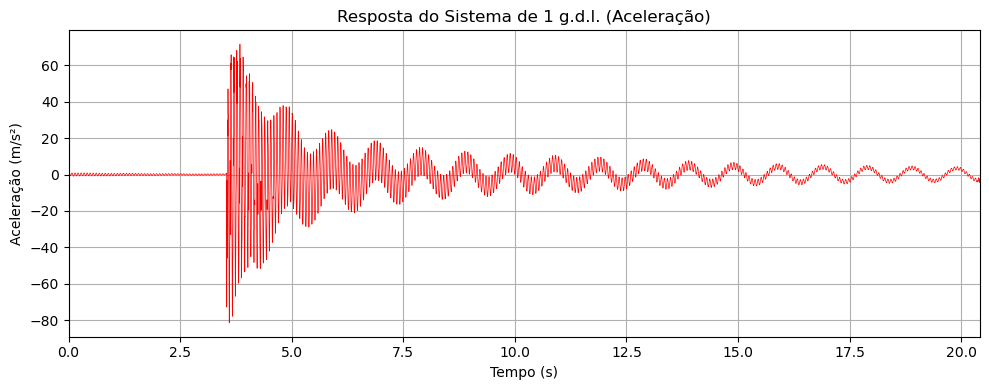

In [30]:
# 1. Primeira derivada (Velocidade)
vel = u.differentiate()

# 2. Segunda derivada usando Equilíbrio Dinâmico (Livre de Ruído Numérico!)
wn = 2 * np.pi * fn
c = 2 * zeta * m * wn
k = m * wn**2

# acc_z_mrpy[0] é a nossa Força original medida
acc_resp_array = (acc_z_mrpy[0] / m) - (c / m)*vel[0] - (k / m)*u[0]

# 3. Os "prints" com os resultados exigidos pelo professor
print(f"ACELERAÇÃO DA RESPOSTA - Pico máximo: {np.max(np.abs(acc_resp_array)):.2f} m/s²")
print(f"ACELERAÇÃO DA RESPOSTA - Valor R.M.S.: {np.sqrt(np.mean(acc_resp_array**2)):.2f} m/s²")

# 4. Gráfico final da Aceleração
plt.figure(7, figsize=(10, 4), clear=True)
plt.plot(u.t_axis(), acc_resp_array, color='red', linewidth=0.5)

# Textos e formatação do gráfico
plt.title('Resposta do Sistema de 1 g.d.l. (Aceleração)')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.grid(True)
plt.xlim(0, data.Td)
plt.tight_layout()